# K-means implementation
## Step 1 - generating a synthetic dataset

The sythetic dataset will be a simple 

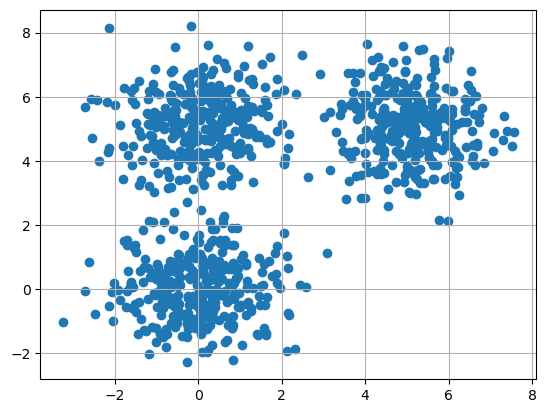

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
np.random.seed(42)

n = 1000

# cluster sizes
n1 = n2 = n3 = n // 3

# define means manually
mean1 = [0, 0]
mean2 = [5, 5]
mean3 = [0, 5]

# generate clusters
c1 = np.random.randn(n1, 2) + mean1
c2 = np.random.randn(n2, 2) + mean2
c3 = np.random.randn(n3, 2) + mean3

X = np.vstack((c1, c2, c3))

plt.scatter(X[:, 0], X[:, 1])
plt.grid(True)
plt.show()

## Initializing the centroids

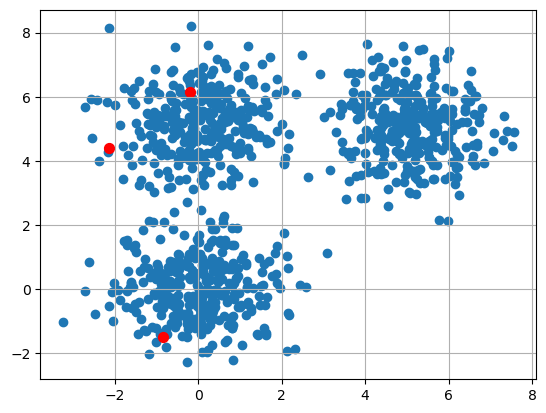

In [71]:
k = 3
centroids = []

for i in range(k):
    centroid = X[np.random.choice(X.shape[0])]
    centroids.append(centroid)

centroids = np.array(centroids)
centroids
plt.scatter(X[:, 0], X[:, 1])
plt.scatter(centroids[:, 0], centroids[:, 1],
            color='red', marker='.', s=200)

plt.grid(True)
plt.show()


## Define labels - distance from centroids for each point

In [60]:
def get_labels(X, centroids):
    distances = []
    
    for centroid in centroids:
        dist = np.sqrt(np.sum((X - centroid)**2, axis=1))
        distances.append(dist)
    
    distances = np.array(distances).T
    
    return np.argmin(distances, axis=1)

In [61]:
labels = get_labels(X,centroids)
counts = np.bincount(labels)

for i, count in enumerate(counts):
    print(f"Cluster {i}: {count} points")

Cluster 0: 335 points
Cluster 1: 332 points
Cluster 2: 332 points


## Update the centroids

In [62]:
def new_centroids(X, labels, k):
    centroids = []
    
    for i in range(k):
        points = X[labels == i]
        
        if len(points) == 0:
            centroid = X[np.random.randint(0, X.shape[0])]
        else:
            centroid = points.mean(axis=0)  
            
        centroids.append(centroid)   
        
    return np.array(centroids)

In [50]:
def random_centroids(X, k):
    indices = np.random.choice(X.shape[0], k, replace=False)
    return X[indices]

In [63]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

In [64]:
def plot_clusters(X, labels, centroids, iteration):
    clear_output(wait=True)
    
    plt.title(f"Iteration {iteration}")
    
    plt.scatter(X[:, 0], X[:, 1], c=labels, alpha=0.6)
    
    plt.scatter(centroids[:, 0], centroids[:, 1],
                color='red', marker='.', s=200)
    
    plt.grid(True)
    plt.show()

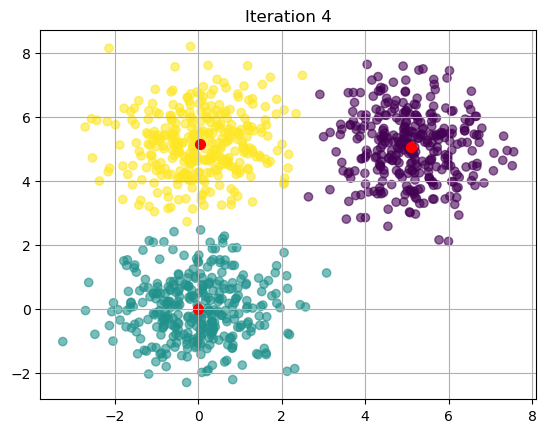

Converged at iteration 4


In [73]:
max_iterations = 100
k = 3

centroids = random_centroids(X, k)
iteration = 0

for iteration in range(max_iterations):
    
    old_centroids = centroids.copy()
    
    labels = get_labels(X, centroids)
    centroids = new_centroids(X, labels, k)
    
    plot_clusters(X, labels, centroids, iteration)
    
    if np.allclose(centroids, old_centroids):
        print(f"Converged at iteration {iteration}")
        break